Import thư viện


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

**Thiết lập device**

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cpu


Tiền xử lý dữ liệu

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

Tải dữ liệu

In [4]:
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)

# Tạo DataLoader để băm dữ liệu thành các batch nhỏ (ví dụ 64 ảnh/batch)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# Tải tập test (đã có sẵn, chỉ cần set train=False)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.65MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.50MB/s]


Định nghĩa model CNN

In [5]:
class CNN_Fashion(nn.Module):
    def __init__(self):
        super(CNN_Fashion, self).__init__()

        # Khối 1
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.mp1= nn.MaxPool2d(2)

        # Khối 2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.mp2= nn.MaxPool2d(2)

        # Khối 3
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()

        # Fully Connected
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 7 * 7, 256)
        self.relu_fc = nn.ReLU()
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.mp1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.mp2(x)
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu_fc(x)
        x = self.drop(x)
        x = self.fc2(x)
        logits = x
        return logits

model = CNN_Fashion().to(device)
print(model)


CNN_Fashion(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (mp1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (mp2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=6272, out_features=256, bias=True)
  (relu_fc): ReLU()
  (drop): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


Loss, optimizer, scheduler

In [6]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = 5, gamma = 0.5)

Vòng lặp train

In [7]:
epochs = 15


train_losses = []
test_accuracies = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    epoch_loss = 0.0
    for i, (x,y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        z = model(x)
        
        loss = loss_function(z, y)

        loss.backward()

        optimizer.step()


        epoch_loss += loss.item()

        running_loss += loss.item()

        if i % 300 == 299:    
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / 300:.4f}')
            running_loss = 0.0
    scheduler.step()
    train_losses.append(epoch_loss / len(train_loader))
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    acc = 100 * correct / total
    test_accuracies.append(acc)
    print(f'Epoch {epoch + 1} - Test Accuracy: {100 * correct / total:.2f}%')

print("Huấn luyện hoàn tất!")


[Epoch 1, Batch 300] Loss: 0.5357
[Epoch 1, Batch 600] Loss: 0.3874
[Epoch 1, Batch 900] Loss: 0.3447
Epoch 1 - Test Accuracy: 89.01%
[Epoch 2, Batch 300] Loss: 0.2925
[Epoch 2, Batch 600] Loss: 0.2846
[Epoch 2, Batch 900] Loss: 0.2840
Epoch 2 - Test Accuracy: 90.48%
[Epoch 3, Batch 300] Loss: 0.2451
[Epoch 3, Batch 600] Loss: 0.2440
[Epoch 3, Batch 900] Loss: 0.2420
Epoch 3 - Test Accuracy: 91.61%
[Epoch 4, Batch 300] Loss: 0.2119
[Epoch 4, Batch 600] Loss: 0.2087
[Epoch 4, Batch 900] Loss: 0.2108
Epoch 4 - Test Accuracy: 91.27%
[Epoch 5, Batch 300] Loss: 0.1808
[Epoch 5, Batch 600] Loss: 0.1847
[Epoch 5, Batch 900] Loss: 0.1855
Epoch 5 - Test Accuracy: 91.54%
[Epoch 6, Batch 300] Loss: 0.1414
[Epoch 6, Batch 600] Loss: 0.1406
[Epoch 6, Batch 900] Loss: 0.1283
Epoch 6 - Test Accuracy: 92.65%
[Epoch 7, Batch 300] Loss: 0.1131
[Epoch 7, Batch 600] Loss: 0.1176
[Epoch 7, Batch 900] Loss: 0.1246
Epoch 7 - Test Accuracy: 92.75%
[Epoch 8, Batch 300] Loss: 0.0913
[Epoch 8, Batch 600] Loss: 0

Lưu model

In [8]:
torch.save(model.state_dict(), 'fashion_cnn.pth')

Vẽ đồ thị

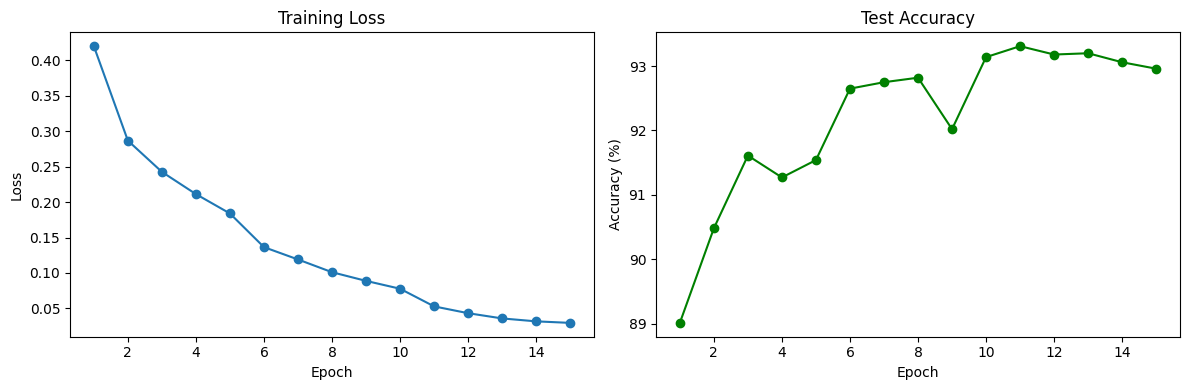

In [9]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, epochs + 1), train_losses, marker='o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(range(1, epochs + 1), test_accuracies, marker='o', color='green')
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()